In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
data = {
    "years_of_experience": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "salary": [35000, 37000, 42000, 50000, 55000, 61000, 67000, 72000, 78000, 83000]
}

df = pd.DataFrame(data)
df

,years_of_experience,salary
0,1,35000
1,2,37000
2,3,42000
3,4,50000
4,5,55000
5,6,61000
6,7,67000
7,8,72000
8,9,78000
9,10,83000


In [3]:
x = df[["years_of_experience"]]
y = df["salary"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)



### Underfitting 

In [4]:
model = DecisionTreeRegressor(max_depth=1)
model.fit(x_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [5]:
# make predictions
y_pred = model.predict(x_test)

# calculate mean squared error
mse1 = mean_squared_error(y_test, y_pred)

# display the mean squared error
print(f"Mean Squared Error (Underfitting): {mse1}")

Mean Squared Error (Underfitting): 62406250.0


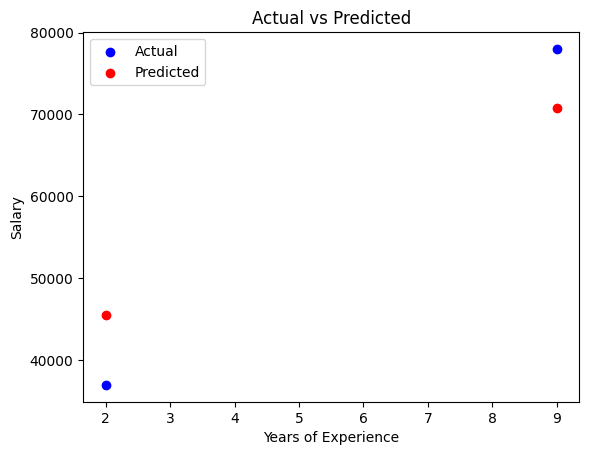

In [6]:
# plot for visualization
plt.scatter(x_test, y_test, color='blue', label='Actual')
plt.scatter(x_test, y_pred, color='red', label='Predicted')
plt.title('Actual vs Predicted')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

### Overfitting

In [7]:
model_02 = DecisionTreeRegressor(max_depth=10)
model_02.fit(x_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [8]:
y_pred = model_02.predict(x_test)
mse2 = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (Overfitting): {mse2}")

Mean Squared Error (Overfitting): 20000000.0


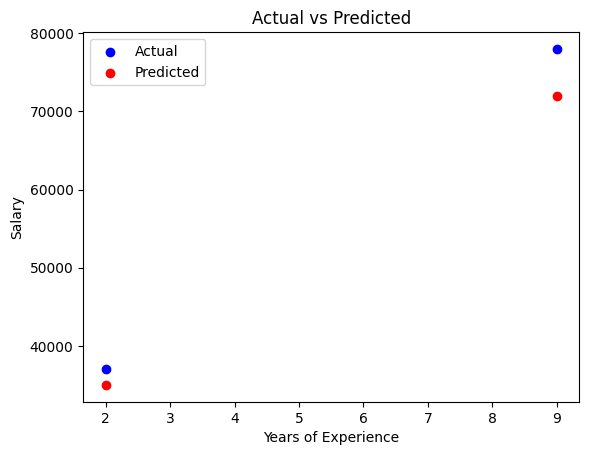

In [9]:
# Plotting

plt.scatter(x_test, y_test, color='blue', label='Actual')
plt.scatter(x_test, y_pred, color='red', label='Predicted')
plt.title('Actual vs Predicted')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

In [12]:
# Error in underfitting is high because the model is too simple to capture the underlying pattern in the data, leading to poor performance on both training and test sets.
print(f"Mean Squared Error (Underfitting): {mse1}")

# Error in overfitting is low on training data but high on test data because the model is too complex and captures noise in the training data, leading to poor generalization to unseen data.
print(f"Mean Squared Error (Overfitting): {mse2}")

Mean Squared Error (Underfitting): 62406250.0
Mean Squared Error (Overfitting): 20000000.0


### Error rates for max_depth 1-10

In [45]:
for i in range(1, 11):
    model = DecisionTreeRegressor(max_depth=i)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"Max Depth: {i}, Mean Squared Error: {mse}")

Max Depth: 1, Mean Squared Error: 62406250.0
Max Depth: 2, Mean Squared Error: 65347222.222222164
Max Depth: 3, Mean Squared Error: 38125000.0
Max Depth: 4, Mean Squared Error: 20000000.0
Max Depth: 5, Mean Squared Error: 20000000.0
Max Depth: 6, Mean Squared Error: 20000000.0
Max Depth: 7, Mean Squared Error: 20000000.0
Max Depth: 8, Mean Squared Error: 20000000.0
Max Depth: 9, Mean Squared Error: 20000000.0
Max Depth: 10, Mean Squared Error: 20000000.0


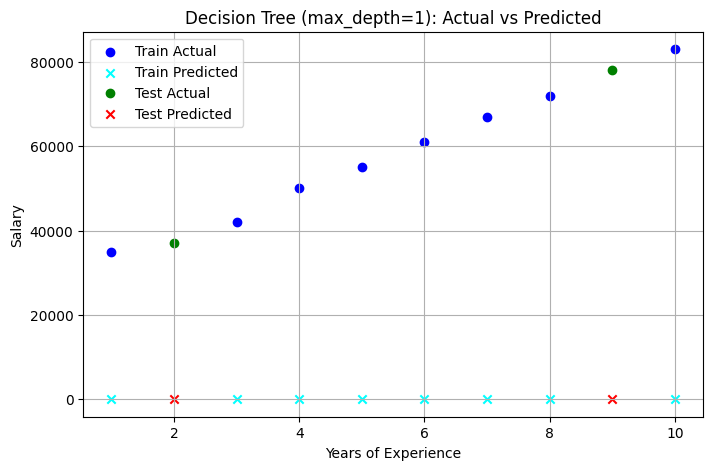

In [13]:
plt.figure(figsize=(8,5))
plt.scatter(x_train, y_train, label='Train Actual', color='blue')
plt.scatter(x_train, x_train, label='Train Predicted', color='cyan', marker='x')
plt.scatter(x_test, y_test, label='Test Actual', color='green')
plt.scatter(x_test, x_test, label='Test Predicted', color='red', marker='x')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Decision Tree (max_depth=1): Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.show()

In [49]:
df_model = DecisionTreeRegressor(max_depth=1)
df_model.fit(x_train, y_train)

y_pred = df_model.predict(x_test)